Saving Smiles in the park group portrait.png to Smiles in the park group portrait (2).png


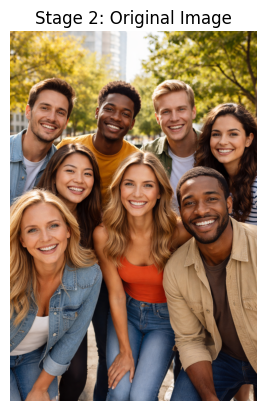

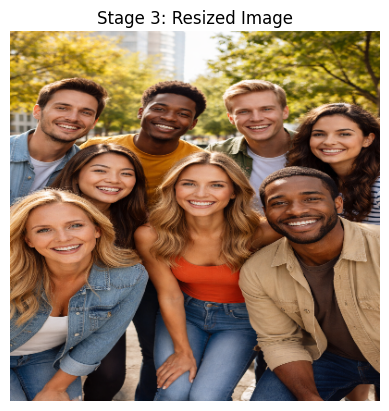

Stage 4: MTCNN Model Loaded
Stage 5: Faces Detected -> 8


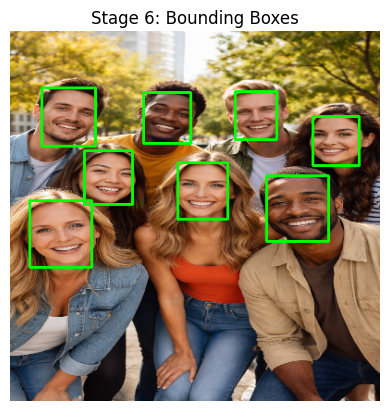

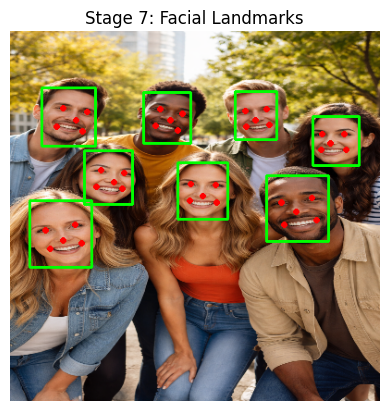

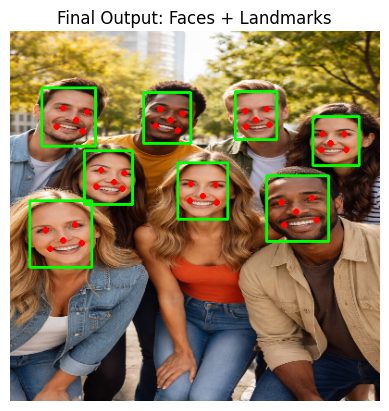

Total Faces Detected: 8


In [4]:
# Install (if needed)
# !pip install mtcnn opencv-python matplotlib pillow

from mtcnn import MTCNN
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files
import numpy as np

# =========================
# Stage 1: Upload Image
# =========================
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# =========================
# Stage 2: Load Image
# =========================
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Stage 2: Original Image")
plt.axis("off")
plt.show()

# =========================
# Stage 3: Preprocessing
# =========================
img_resized = cv2.resize(img_rgb, (400, 400))

plt.imshow(img_resized)
plt.title("Stage 3: Resized Image")
plt.axis("off")
plt.show()

# =========================
# Stage 4: Initialize Model
# =========================
detector = MTCNN()
print("Stage 4: MTCNN Model Loaded")

# =========================
# Stage 5: Face Detection
# =========================
faces = detector.detect_faces(img_resized)
print("Stage 5: Faces Detected ->", len(faces))

# =========================
# Stage 6: Bounding Boxes
# =========================
img_boxes = img_resized.copy()

for face in faces:
    x, y, w, h = face['box']
    cv2.rectangle(img_boxes, (x, y), (x+w, y+h), (0, 255, 0), 2)

plt.imshow(img_boxes)
plt.title("Stage 6: Bounding Boxes")
plt.axis("off")
plt.show()

# =========================
# Stage 7: Landmarks (Eyes, Nose, etc.)
# =========================
img_landmarks = img_boxes.copy()

for face in faces:
    for key, point in face['keypoints'].items():
        cv2.circle(img_landmarks, point, 2, (255, 0, 0), 2)

plt.imshow(img_landmarks)
plt.title("Stage 7: Facial Landmarks")
plt.axis("off")
plt.show()

# =========================
# Stage 8: Final Output
# =========================
plt.imshow(img_landmarks)
plt.title("Final Output: Faces + Landmarks")
plt.axis("off")
plt.show()

print("Total Faces Detected:", len(faces))